In [ ]:
# =========================================================
# HEART DISEASE PREDICTION PROJECT
# =========================================================
# Operations Performed:
# 1. Data Cleaning
# 2. Outlier Detection and Removal
# 3. Data Transformation
# 4. Logistic Regression Model
# 5. kNN Model
# 6. Accuracy Comparison
# =========================================================

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score


In [3]:
# STEP 2 : LOAD HEART DISEASE DATASETS

cleveland = pd.read_csv("Cleavland.csv", header= None)
hungarian = pd.read_csv("hung.csv", header= None)
switzerland = pd.read_csv("Switzerland.csv", header= None)


In [4]:
#combine all datasets into one dataset
data = pd.concat(
    [cleveland, hungarian, switzerland],
    ignore_index=True
)

In [27]:
data = data.iloc[:, [
    0,   # age
    1,   # sex
    2,   # cp
    3,   # trestbps
    4,   # chol
    5,   # fbs
    6,   # restecg
    7,   # thalach
    8,   # exang
    9,   # oldpeak
    10,  # slope
    11,  # ca
    12,  # thal
    13   # num
]]

In [28]:
data.columns = [
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'num'
]

In [29]:
#display first 5 rows
print("First 5 rows of dataset")
print(data.head())

First 5 rows of dataset
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
1  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
4  56.0  1.0  2.0     120.0  236.0  0.0      0.0    178.0    0.0      0.8   
7  63.0  1.0  4.0     130.0  254.0  0.0      2.0    147.0    0.0      1.4   
9  57.0  1.0  4.0     140.0  192.0  0.0      0.0    148.0    0.0      0.4   

   slope   ca  thal  num  
1    2.0  2.0   7.0  1.0  
3    1.0  0.0   3.0  0.0  
4    1.0  0.0   3.0  0.0  
7    2.0  1.0   7.0  2.0  
9    2.0  0.0   6.0  0.0  


In [30]:
#display shape of dataset
print("\nNumber of rows and columns")
print(data.shape)


Number of rows and columns
(396, 14)


In [31]:
print("\nCOLUMN NAMES")
print(data.columns)


COLUMN NAMES
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')


In [32]:
# STEP 3 : DATA CLEANING

# 3.1 Replace '?' with NaN
data.replace('?', np.nan, inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0.0
7,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2.0
9,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,55.5,1.0,3.0,130.0,241.5,0.0,0.5,153.0,0.0,0.8,2.0,0.0,3.0,0.0
660,55.5,1.0,3.0,130.0,241.5,0.0,0.5,153.0,0.0,0.8,2.0,0.0,3.0,0.0
667,55.5,1.0,3.0,130.0,241.5,0.0,0.5,153.0,0.0,0.8,2.0,0.0,3.0,0.0
679,55.5,1.0,3.0,130.0,241.5,0.0,0.5,153.0,0.0,0.8,2.0,0.0,3.0,0.0


In [33]:
# 3.2 Replace -9 with NaN
# (-9 represents missing values in dataset)
data.replace(-9, np.nan, inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0.0
7,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2.0
9,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,55.5,1.0,3.0,130.0,241.5,0.0,0.5,153.0,0.0,0.8,2.0,0.0,3.0,0.0
660,55.5,1.0,3.0,130.0,241.5,0.0,0.5,153.0,0.0,0.8,2.0,0.0,3.0,0.0
667,55.5,1.0,3.0,130.0,241.5,0.0,0.5,153.0,0.0,0.8,2.0,0.0,3.0,0.0
679,55.5,1.0,3.0,130.0,241.5,0.0,0.5,153.0,0.0,0.8,2.0,0.0,3.0,0.0


In [35]:
# 3.3 Convert all columns into numeric type
for column in data.columns:
    data[column] = pd.to_numeric(
        data[column],
        errors='coerce'
    )

In [36]:
# 3.4 Remove duplicate rows
data.drop_duplicates(inplace=True)

In [37]:
# Display cleaned dataset
# -----------------------------------------

print("\nDATASET AFTER CLEANING")
print(data.shape)


DATASET AFTER CLEANING
(178, 14)


In [38]:
# 3.5 Fill missing values using median
data = data.fillna(data.median())

In [39]:
print("\nMissing values after cleaning")
print(data.isnull().sum())


Missing values after cleaning
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [13]:
# # STEP 4 : OUTLIER DETECTION AND REMOVAL
# # =========================================================
# # We use IQR Method
# # IQR = Inter Quartile Range

# from scipy import stats

# #calculate z-score
# z_scores = np.abs(stats.zscore(data))

# #keep rows where z-score is less than 3
# data = data[(z_scores < 3).all(axis=1)]

# print("\nDataset shape after removing outliers")
# print(data.shape)



Dataset shape after removing outliers
(396, 34)


In [40]:
# STEP 5: DATA TRANSFORMATION

# Last column is the target column
# Target column contains:
# 0 = No Heart Disease
# 1,2,3,4 = Heart Disease

target_column = 'num'

#convert target column into binary values
data[target_column] = data[target_column].apply(
    lambda x: 0 if x == 0 else 1
)



In [41]:
#separate input and output
X = data.drop(target_column, axis=1)
Y= data[target_column]

In [43]:
#display target values
print("\n Target value counts")
print(Y.value_counts())


 Target value counts
num
0    112
1     66
Name: count, dtype: int64


In [44]:
#feature scaling
#standardscaler convert data into similar scale for better performance

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [45]:
#split data into training and testing
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size= 0.20, random_state=42)
print("\nTraining data size")
print(X_train.shape)

print("\nTesting data size")
print(X_test.shape)


Training data size
(142, 13)

Testing data size
(36, 13)


In [ ]:
| Transformation | Purpose                        |
| -------------- | ------------------------------ |
| Scaling        | Make values similar            |
| Normalization  | Convert values between 0 and 1 |
| Encoding       | Convert text to numbers        |
| Aggregation    | Combine data                   |
| Smoothing      | Remove noise                   |


In [46]:
#logistic regression model

# Create model

logistic_model = LogisticRegression(max_iter=1000)

# Train model

logistic_model.fit(X_train, Y_train)

# Predict output

logistic_prediction = logistic_model.predict(X_test)

# Calculate accuracy

logistic_accuracy = accuracy_score(
    Y_test,
    logistic_prediction
)

In [47]:
print("Result")
print("Accuracy =", round(logistic_accuracy * 100, 2), "%"
     )

Result
Accuracy = 80.56 %


In [48]:
#KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [49]:
#train model
knn_model.fit(
    X_train,
    Y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [50]:
#predict output
knn_prediction = knn_model.predict(X_test)

In [51]:
#accuracy
knn_accuracy = accuracy_score(Y_test, knn_prediction)

In [52]:
#knn model result
print("Accuracy =", round(knn_accuracy * 100, 2), "%")

Accuracy = 75.0 %


In [53]:
#model comparision
print(
    "Logistic Regression Accuracy :",
    round(logistic_accuracy * 100, 2),
    "%"
)

print(
    "kNN Accuracy :",
    round(knn_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy : 80.56 %
kNN Accuracy : 75.0 %


In [54]:
#compare models

if logistic_accuracy > knn_accuracy:
    print("\nLogistic is better.")
elif knn_accuracy > logistic_accuracy:
    print("\nKNN is better.")
else:
    print("\nBoth better")


Logistic is better.


In [59]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 299.6 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/8.2 MB 299.6 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/8.2 MB 299.6 kB/s eta 0:00:26
   -- ---

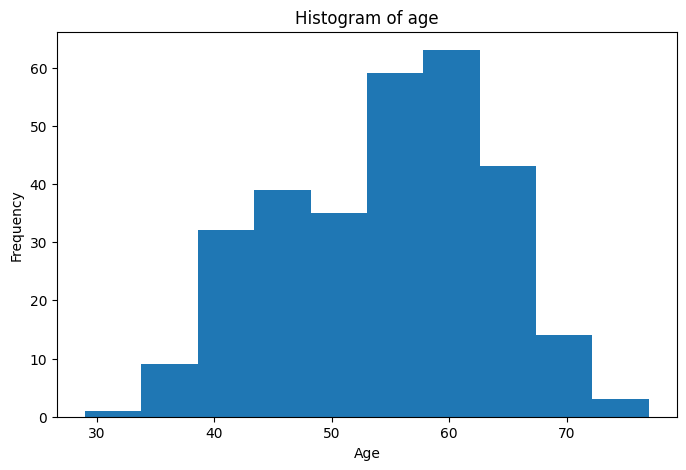

In [60]:
#histogram
#distribution of patient ages
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(data['age'], bins=10)
plt.title("Histogram of age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

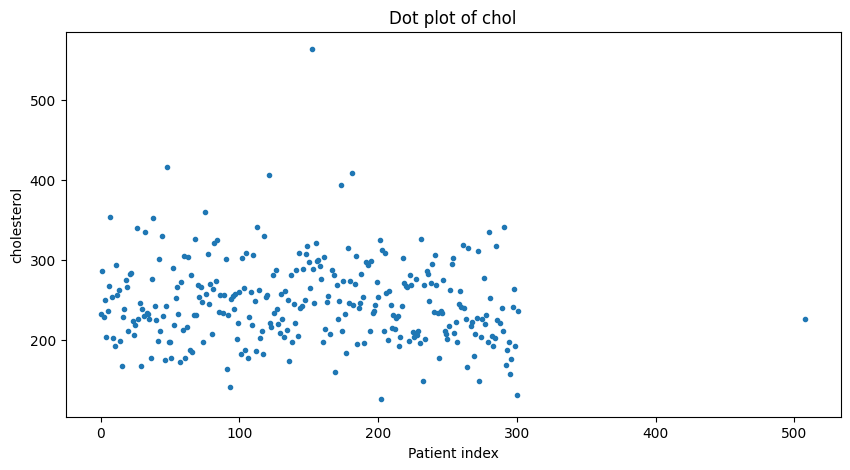

In [62]:
#dot plot
#display chol values of patient

plt.figure(figsize=(10,5))
plt.plot(data['chol'], '.')
plt.title("Dot plot of chol")
plt.xlabel("Patient index")
plt.ylabel("cholesterol")
plt.show()

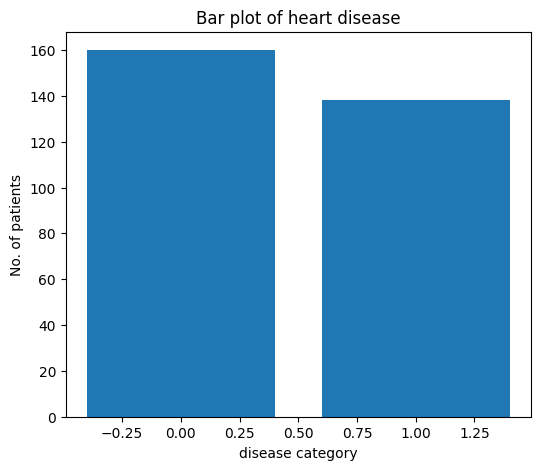

In [65]:
heart_count = data['num'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(
    heart_count.index,
    heart_count.values
)
plt.title("Bar plot of heart disease")
plt.xlabel("disease category")
plt.ylabel("No. of patients")
plt.show()

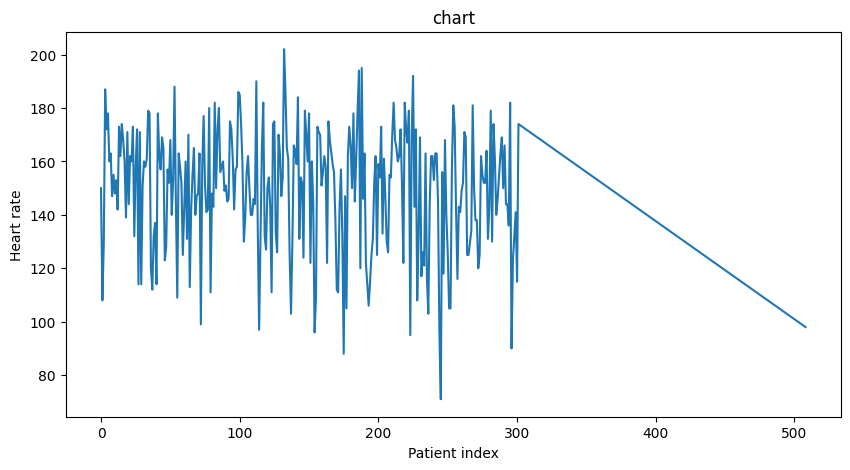

In [66]:
#line chart
#show variation in max heart rate
plt.figure(figsize=(10,5))
plt.plot(data['thalach'])
plt.title("chart")
plt.xlabel("Patient index")
plt.ylabel("Heart rate")
plt.show()

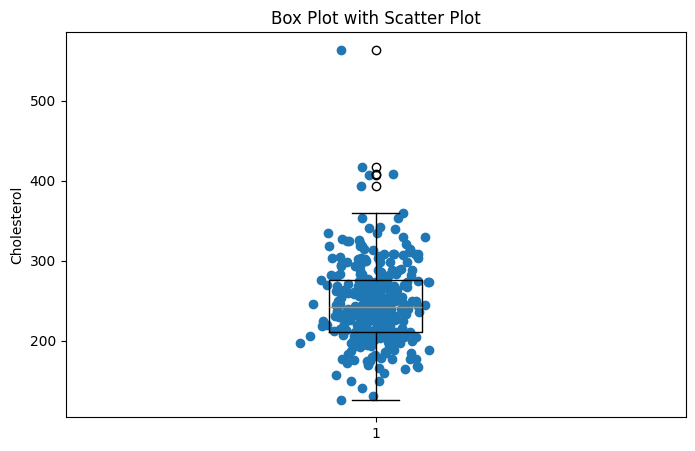

In [67]:
# GRAPH 5 : BOX PLOT + SCATTER PLOT
# =========================================================
# OBJECTIVE:
# To identify spread and outliers in cholesterol.
# =========================================================

plt.figure(figsize=(8,5))

# Box Plot

plt.boxplot(data['chol'])

# Scatter Plot

x = np.random.normal(
    1,
    0.04,
    size=len(data['chol'])
)

plt.scatter(
    x,
    data['chol']
)

plt.title("Box Plot with Scatter Plot")

plt.ylabel("Cholesterol")

plt.show()

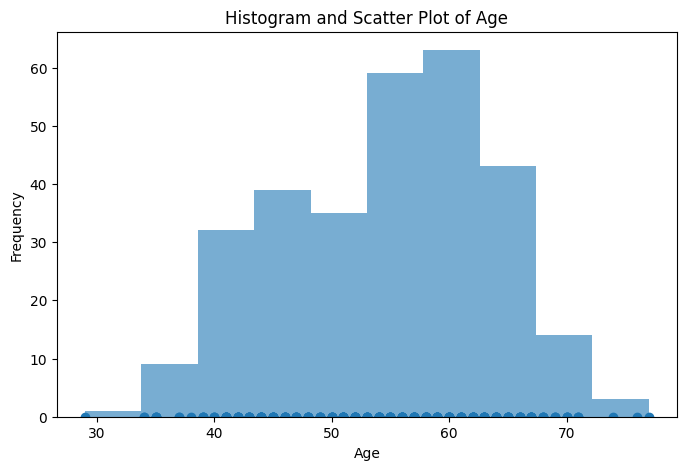

In [68]:

# =========================================================
# GRAPH 6 : HISTOGRAM + SCATTER PLOT
# =========================================================
# OBJECTIVE:
# To compare age distribution and age spread.
# =========================================================

plt.figure(figsize=(8,5))

# Histogram

plt.hist(
    data['age'],
    alpha=0.6
)

# Scatter Plot

plt.scatter(
    data['age'],
    np.zeros(len(data['age']))
)

plt.title("Histogram and Scatter Plot of Age")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()


In [56]:
# =========================================================
# HEART DISEASE PREDICTION PROJECT
# =========================================================
# Operations Performed:
# 1. Data Cleaning
# 2. Data Transformation
# 3. Logistic Regression Model
# 4. kNN Model
# 5. Accuracy Comparison
# =========================================================


# =========================================================
# STEP 1 : IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

# Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Accuracy Metric

from sklearn.metrics import accuracy_score


# =========================================================
# STEP 2 : LOAD HEART DISEASE DATASETS
# =========================================================

# Read Excel files
# header=None prevents first row becoming column names

cleveland = pd.read_csv(
    "Cleavland.csv",
    header=None
)

hungarian = pd.read_csv(
    "hung.csv",
    header=None
)

switzerland = pd.read_csv(
    "Switzerland.csv",
    header=None
)

# Combine all datasets

data = pd.concat(
    [cleveland, hungarian, switzerland],
    ignore_index=True
)

print("ORIGINAL DATASET SHAPE")
print(data.shape)


# =========================================================
# STEP 3 : SELECT REQUIRED 14 COLUMNS
# =========================================================

# Select only important columns

data = data.iloc[:, [

    0,   # age
    1,   # sex
    2,   # cp
    3,   # trestbps
    4,   # chol
    5,   # fbs
    6,   # restecg
    7,   # thalach
    8,   # exang
    9,   # oldpeak
    10,  # slope
    11,  # ca
    12,  # thal
    13   # num

]]

# Add column names

data.columns = [

    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'num'
]

# Display first 5 rows

print("\nFIRST 5 ROWS")
print(data.head())

# Dataset shape

print("\nDATASET SHAPE")
print(data.shape)

# Display column names

print("\nCOLUMN NAMES")
print(data.columns)


# =========================================================
# STEP 4 : DATA CLEANING
# =========================================================

# -----------------------------------------
# Replace '?' with NaN
# -----------------------------------------

data.replace('?', np.nan, inplace=True)

# -----------------------------------------
# Replace -9 with NaN
# -----------------------------------------

data.replace(-9, np.nan, inplace=True)

# -----------------------------------------
# Convert all columns to numeric
# -----------------------------------------

for column in data.columns:

    data[column] = pd.to_numeric(
        data[column],
        errors='coerce'
    )

# -----------------------------------------
# Remove rows having missing values
# -----------------------------------------

data.dropna(inplace=True)

# -----------------------------------------
# Remove duplicate rows
# -----------------------------------------

data.drop_duplicates(inplace=True)

# -----------------------------------------
# Display cleaned dataset
# -----------------------------------------

print("\nDATASET AFTER CLEANING")
print(data.shape)


# =========================================================
# STEP 5 : DATA TRANSFORMATION
# =========================================================

# Target column

target_column = 'num'

# Convert:
# 0 = No Heart Disease
# 1,2,3,4 = Heart Disease

data[target_column] = data[target_column].apply(

    lambda x: 0 if x == 0 else 1
)

# Separate input and output

X = data.drop(target_column, axis=1)

Y = data[target_column]

# Display target values

print("\nTARGET VALUE COUNTS")
print(Y.value_counts())

# -----------------------------------------
# Feature Scaling
# -----------------------------------------

# StandardScaler converts data into
# similar scale

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# =========================================================
# STEP 6 : SPLIT DATA INTO TRAINING AND TESTING
# =========================================================

X_train, X_test, Y_train, Y_test = train_test_split(

    X_scaled,
    Y,

    test_size=0.20,

    random_state=42
)

print("\nTRAINING DATA SIZE")
print(X_train.shape)

print("\nTESTING DATA SIZE")
print(X_test.shape)


# =========================================================
# STEP 7 : LOGISTIC REGRESSION MODEL
# =========================================================

# Create model

logistic_model = LogisticRegression(
    max_iter=1000
)

# Train model

logistic_model.fit(
    X_train,
    Y_train
)

# Predict output

logistic_prediction = logistic_model.predict(
    X_test
)

# Calculate accuracy

logistic_accuracy = accuracy_score(

    Y_test,
    logistic_prediction
)

print("\n===================================")
print("LOGISTIC REGRESSION RESULT")
print("===================================")

print(
    "Accuracy =",
    round(logistic_accuracy * 100, 2),
    "%"
)


# =========================================================
# STEP 8 : kNN MODEL
# =========================================================

# Create kNN model

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train model

knn_model.fit(
    X_train,
    Y_train
)

# Predict output

knn_prediction = knn_model.predict(
    X_test
)

# Calculate accuracy

knn_accuracy = accuracy_score(

    Y_test,
    knn_prediction
)

print("\n===================================")
print("kNN MODEL RESULT")
print("===================================")

print(
    "Accuracy =",
    round(knn_accuracy * 100, 2),
    "%"
)


# =========================================================
# STEP 9 : MODEL COMPARISON
# =========================================================

print("\n===================================")
print("MODEL COMPARISON")
print("===================================")

print(
    "Logistic Regression Accuracy :",
    round(logistic_accuracy * 100, 2),
    "%"
)

print(
    "kNN Accuracy :",
    round(knn_accuracy * 100, 2),
    "%"
)

# Compare models

if logistic_accuracy > knn_accuracy:

    print(
        "\nLogistic Regression performs better."
    )

elif knn_accuracy > logistic_accuracy:

    print(
        "\nkNN performs better."
    )

else:

    print(
        "\nBoth models perform equally."
    )


# =========================================================
# END OF PROJECT
# =========================================================

ORIGINAL DATASET SHAPE
(720, 14)

FIRST 5 ROWS
    age  sex   cp trestbps   chol  fbs restecg thalach exang oldpeak slope  \
0  63.0  1.0  1.0    145.0  233.0  1.0     2.0   150.0   0.0     2.3   3.0   
1  67.0  1.0  4.0    160.0  286.0  0.0     2.0   108.0   1.0     1.5   2.0   
2  67.0  1.0  4.0    120.0  229.0  0.0     2.0   129.0   1.0     2.6   2.0   
3  37.0  1.0  3.0    130.0  250.0  0.0     0.0   187.0   0.0     3.5   3.0   
4  41.0  0.0  2.0    130.0  204.0  0.0     2.0   172.0   0.0     1.4   1.0   

    ca thal  num  
0  0.0  6.0    0  
1  3.0  3.0    2  
2  2.0  7.0    1  
3  0.0  3.0    0  
4  0.0  3.0    0  

DATASET SHAPE
(720, 14)

COLUMN NAMES
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

DATASET AFTER CLEANING
(298, 14)

TARGET VALUE COUNTS
num
0    160
1    138
Name: count, dtype: int64

TRAINING DATA SIZE
(238, 13)

TESTING DATA SIZE
(60, 13)

LOGISTIC REGRESS

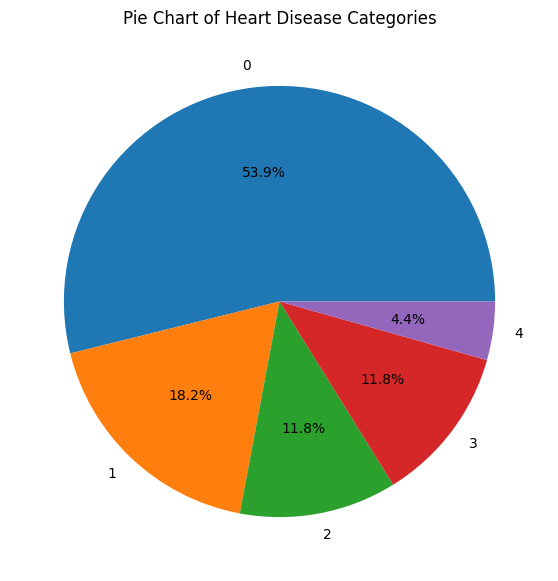

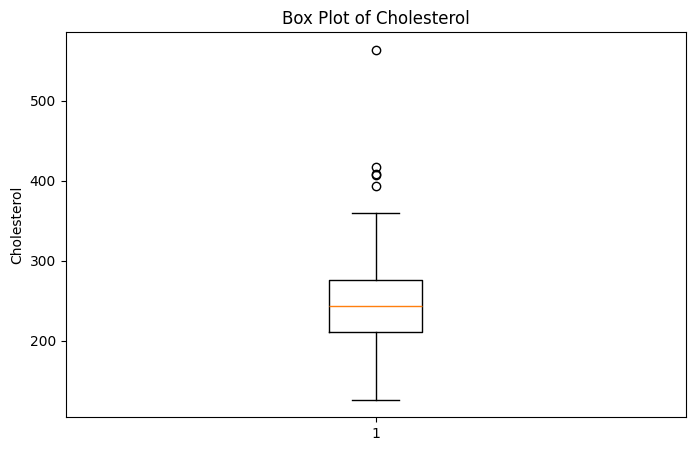

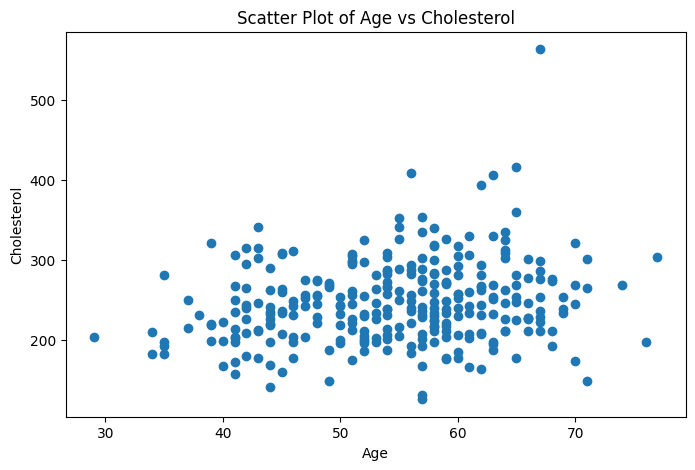

In [4]:
# =========================================================
# HEART DISEASE DATA VISUALIZATION
# PIE CHART, BOX PLOT, SCATTER PLOT
# =========================================================

# =========================================================
# STEP 1 : IMPORT LIBRARIES
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# =========================================================
# STEP 2 : LOAD DATASET
# =========================================================

# Read dataset

data = pd.read_csv(
    "Cleavland.csv",
    header=None
)

# Select first 14 columns

data = data.iloc[:, 0:14]

# Add column names

data.columns = [

    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'num'
]

# Replace missing values

data.replace('?', np.nan, inplace=True)

# Convert columns to numeric

for column in data.columns:

    data[column] = pd.to_numeric(
        data[column],
        errors='coerce'
    )

# Remove missing values

data.dropna(inplace=True)


# =========================================================
# GRAPH 1 : PIE CHART
# =========================================================
# OBJECTIVE:
# To show percentage of heart disease patients.
# =========================================================

# Count heart disease values

heart_count = data['num'].value_counts()

# Plot pie chart

plt.figure(figsize=(7,7))

plt.pie(
    heart_count.values,
    labels=heart_count.index,
    autopct='%1.1f%%'
)

plt.title("Pie Chart of Heart Disease Categories")

plt.show()


# =========================================================
# GRAPH 2 : BOX PLOT
# =========================================================
# OBJECTIVE:
# To identify spread and outliers in cholesterol.
# =========================================================

plt.figure(figsize=(8,5))

plt.boxplot(data['chol'])

plt.title("Box Plot of Cholesterol")

plt.ylabel("Cholesterol")

plt.show()


# =========================================================
# GRAPH 3 : SCATTER PLOT
# =========================================================
# OBJECTIVE:
# To show relationship between Age and Cholesterol.
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    data['age'],
    data['chol']
)

plt.title("Scatter Plot of Age vs Cholesterol")

plt.xlabel("Age")

plt.ylabel("Cholesterol")

plt.show()


# =========================================================
# END
# =========================================================